#Proyecto 2 TAM



*   Juan David Ramirez
*   Juan Diego Carreño



##1. Introducción y planteamiento del problema

En este proyecto abordaremos el problema de segmentar clientes a partir de sus características y hábitos de compra, con el fin de identificar grupos con comportamientos similares. Esta tarea es relevante en el contexto empresarial porque permite diseñar estrategias más efectivas de marketing, fidelización y personalización de servicios.

Para ello, primero aplicaremos K-Means clustering, que nos permitirá descubrir segmentos naturales dentro del conjunto de clientes sin etiquetas previas. Luego, utilizaremos esos segmentos como etiquetas para entrenar un árbol de decisión, con el objetivo de predecir a qué grupo pertenecería un nuevo cliente según sus características.

Este enfoque nos permitirá no solo identificar perfiles de clientes, sino también construir un modelo predictivo útil para apoyar futuras decisiones comerciales.

###1.1 Estructura del notebook

Para abordar el problema dividimos el notebbok bajo la siguiente estructura



1.   Introducción y planteamiento del problema
2.   Carga y comprensión del dataset


1.   Análisis exploratorio de datos (EDA)

1.   Preprocesamiento de datos

1.   Determinación del número óptimo de clusters

1.   Aplicación de K-Means y segmentación

1.   Interpretación de clusters
2.   Entrenamiento del árbol de decisión supervisado


2.   Evaluación del modelo


2.   Importancia de variables


2.   Conclusiones finales








##2. Carga y comprensión del dataset

A continuación, cargamos el dataset que será utilizado en el desarrollo del proyecto. Este conjunto de datos contiene información demográfica, transaccional y de comportamiento de los clientes, la cual servirá como base para identificar patrones de segmentación y construir posteriormente los modelos de aprendizaje de máquina.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/dataset_proyecto_2.csv")

In [3]:
df.head()

,edad,ingresos_anuales,cantidad_compras,valor_promedio_compra,frecuencia_compras_mensual,dispositivo_utilizado,fuente_trafico,dias_desde_ultima_compra,valor_total_gastado,satisfaccion_cliente,metodo_pago,participacion_programa_lealtad,productos_adquiridos
0,28,90455,4,135,0.921436,tablet,redes sociales,230,3369,2.929789,tarjeta crédito,0,computadoras
1,35,55842,19,367,5.321630,móvil,búsqueda orgánica,17,8276,3.446550,tarjeta crédito,1,accesorios
2,30,23268,39,257,9.021315,móvil,búsqueda orgánica,13,2216,4.034947,tarjeta crédito,0,accesorios
3,35,60841,8,862,2.865878,móvil,búsqueda orgánica,72,8003,3.466717,paypal,0,electrodomésticos
4,25,100485,19,444,7.365862,móvil,redes sociales,57,8550,4.310355,paypal,1,móviles


Con los datos cargados correctamente, procederemos a explorar sus características principales para entender su composición y preparar el preprocesamiento necesario.

## 3. Análisis exploratorio de datos (EDA)

### 3.1 Validación de datos

Antes de iniciar el análisis exploratorio detallado, realizamos una validación inicial de calidad de datos para verificar consistencia en tipos de variables, rangos permitidos, categorías registradas, duplicados y valores faltantes. Esta revisión permite identificar posibles errores que deben corregirse antes de continuar con el análisis.

In [4]:
print("=" * 60)
print("1. TIPOS DE DATOS")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("2. DIMENSIONES DEL DATASET")
print("=" * 60)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

print("\n" + "=" * 60)
print("3. RANGOS DE VARIABLES NUMÉRICAS")
print("=" * 60)
rangos_esperados = {
    "edad":                       (18, 100),
    "ingresos_anuales":           (0, None),
    "cantidad_compras":           (0, None),
    "valor_promedio_compra":      (0, None),
    "frecuencia_compras_mensual": (0, None),
    "dias_desde_ultima_compra":   (0, None),
    "valor_total_gastado":        (0, None),
    "satisfaccion_cliente":        (1, 5),
    "participacion_programa_lealtad": (0, 1),
}
for col, (lo, hi) in rangos_esperados.items():
    col_min, col_max = df[col].min(), df[col].max()
    fuera_bajo = (df[col] < lo).sum() if lo is not None else 0
    fuera_alto = (df[col] > hi).sum() if hi is not None else 0
    flag = "⚠️" if (fuera_bajo + fuera_alto) > 0 else "✅"
    print(f"{flag} {col}: min={col_min:.2f}, max={col_max:.2f} | "
          f"fuera de rango: {fuera_bajo + fuera_alto}")

print("\n" + "=" * 60)
print("4. VALORES CATEGÓRICOS ÚNICOS")
print("=" * 60)
cat_cols = ["dispositivo_utilizado", "fuente_trafico", "metodo_pago", "productos_adquiridos"]
for col in cat_cols:
    unicos = df[col].unique()
    print(f"{col} ({len(unicos)} categorías): {sorted([str(u) for u in unicos])}")

print("\n" + "=" * 60)
print("5. DUPLICADOS")
print("=" * 60)
n_dup = df.duplicated().sum()
flag = "⚠️" if n_dup > 0 else "✅"
print(f"{flag} Filas duplicadas: {n_dup}")

print("\n" + "=" * 60)
print("6. VALORES NULOS")
print("=" * 60)
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos["Nulos"] > 0]
if resumen_nulos.empty:
    print("✅ No se encontraron valores nulos.")
else:
    print(resumen_nulos)

1. TIPOS DE DATOS
edad                                int64
ingresos_anuales                    int64
cantidad_compras                    int64
valor_promedio_compra               int64
frecuencia_compras_mensual        float64
dispositivo_utilizado              object
fuente_trafico                     object
dias_desde_ultima_compra            int64
valor_total_gastado                 int64
satisfaccion_cliente              float64
metodo_pago                        object
participacion_programa_lealtad      int64
productos_adquiridos               object
dtype: object

2. DIMENSIONES DEL DATASET
Filas: 9533 | Columnas: 13

3. RANGOS DE VARIABLES NUMÉRICAS
✅ edad: min=18.00, max=69.00 | fuera de rango: 0
✅ ingresos_anuales: min=10003.00, max=199894.00 | fuera de rango: 0
✅ cantidad_compras: min=1.00, max=49.00 | fuera de rango: 0
✅ valor_promedio_compra: min=50.00, max=1498.00 | fuera de rango: 0
✅ frecuencia_compras_mensual: min=0.20, max=14.97 | fuera de rango: 0
✅ dias_desde_ultim

La validación confirmó que el dataset presenta rangos coherentes y no contiene duplicados. Se detectó una inconsistencia tipográfica en metodo_pago y un valor 'nan' registrado como texto en productos_adquiridos, los cuales fueron corregidos. Posteriormente, se eliminaron las dos filas con valores nulos, ya que representan solo el 0.0003% del total, por lo que su exclusión no introduce sesgo apreciable y resulta más adecuada que una imputación innecesaria.

In [5]:
# ── Limpieza previa al EDA ───────────────────────────────────────────────────

# 1. Unificar categoría mal escrita en metodo_pago
df['metodo_pago'] = df['metodo_pago'].replace('tarjeta crédit', 'tarjeta crédito')

# 2. Convertir el string 'nan' a NaN real en productos_adquiridos
df['productos_adquiridos'] = df['productos_adquiridos'].replace('nan', np.nan)

# 3. Eliminar las 2 filas con nulos
df = df.dropna()

# Verificación
print(f"Filas tras limpieza: {len(df)}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")
print(f"\nCategorías metodo_pago: {sorted(df['metodo_pago'].unique())}")
print(f"Categorías productos_adquiridos: {sorted(df['productos_adquiridos'].unique())}")

Filas tras limpieza: 9533
Nulos restantes: 0

Categorías metodo_pago: ['paypal', 'tarjeta crédito', 'transferencia']
Categorías productos_adquiridos: ['accesorios', 'computa', 'computadoras', 'electrodomésticos', 'móviles']


Con los datos ya depurados y consistentes, el siguiente paso será realizar el análisis descriptivo de las variables para explorar la distribución y comportamiento general de los clientes.

### 3.2 Estadísticas descriptivas

In [6]:
import warnings
warnings.filterwarnings('ignore')

num_cols = ['edad', 'ingresos_anuales', 'cantidad_compras', 'valor_promedio_compra',
            'frecuencia_compras_mensual', 'dias_desde_ultima_compra',
            'valor_total_gastado', 'satisfaccion_cliente', 'participacion_programa_lealtad']

cat_cols = ['dispositivo_utilizado', 'fuente_trafico', 'metodo_pago', 'productos_adquiridos']

print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS")
print("=" * 70)
display(df[num_cols].describe().round(2).T)

print("\n" + "=" * 70)
print("DISTRIBUCIÓN — VARIABLES CATEGÓRICAS")
print("=" * 70)
for col in cat_cols:
    freq = df[col].value_counts()
    pct  = (freq / len(df) * 100).round(2)
    tabla = pd.DataFrame({'Frecuencia': freq, 'Porcentaje (%)': pct})
    print(f"\n▶ {col}")
    display(tabla)

ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
edad,9533.0,38.96,13.62,18.0,29.00,35.00,47.00,69.00
ingresos_anuales,9533.0,77111.88,44606.35,10003.0,42587.00,68171.00,109864.00,199894.00
cantidad_compras,9533.0,14.17,12.00,1.0,4.00,9.00,21.00,49.00
valor_promedio_compra,9533.0,434.07,310.21,50.0,199.00,365.00,542.00,1498.00
frecuencia_compras_mensual,9533.0,5.47,4.23,0.2,1.22,5.66,9.30,14.97
dias_desde_ultima_compra,9533.0,98.12,107.36,1.0,12.00,45.00,169.00,364.00
valor_total_gastado,9533.0,7150.74,6344.19,1000.0,2970.00,4632.00,8859.00,29997.00
satisfaccion_cliente,9533.0,3.77,0.72,2.0,3.22,3.83,4.34,5.00
participacion_programa_lealtad,9533.0,0.46,0.50,0.0,0.00,0.00,1.00,1.00



DISTRIBUCIÓN — VARIABLES CATEGÓRICAS

▶ dispositivo_utilizado


,Frecuencia,Porcentaje (%)
dispositivo_utilizado,,
móvil,4207,44.13
PC,3957,41.51
tablet,1369,14.36



▶ fuente_trafico


,Frecuencia,Porcentaje (%)
fuente_trafico,,
redes sociales,4335,45.47
búsqueda orgánica,3524,36.97
email,1674,17.56



▶ metodo_pago


,Frecuencia,Porcentaje (%)
metodo_pago,,
tarjeta crédito,4773,50.07
paypal,2646,27.76
transferencia,2114,22.18



▶ productos_adquiridos


,Frecuencia,Porcentaje (%)
productos_adquiridos,,
accesorios,2830,29.69
computadoras,2324,24.38
móviles,2223,23.32
electrodomésticos,2155,22.61
computa,1,0.01


### 3.3 Visualizaciones descriptivas

Una vez depurados los datos, analizamos la distribución de las variables numéricas y categóricas para identificar patrones generales de comportamiento en los clientes. Este paso permite reconocer tendencias, asimetrías y posibles señales de segmentación antes de aplicar K-Means.

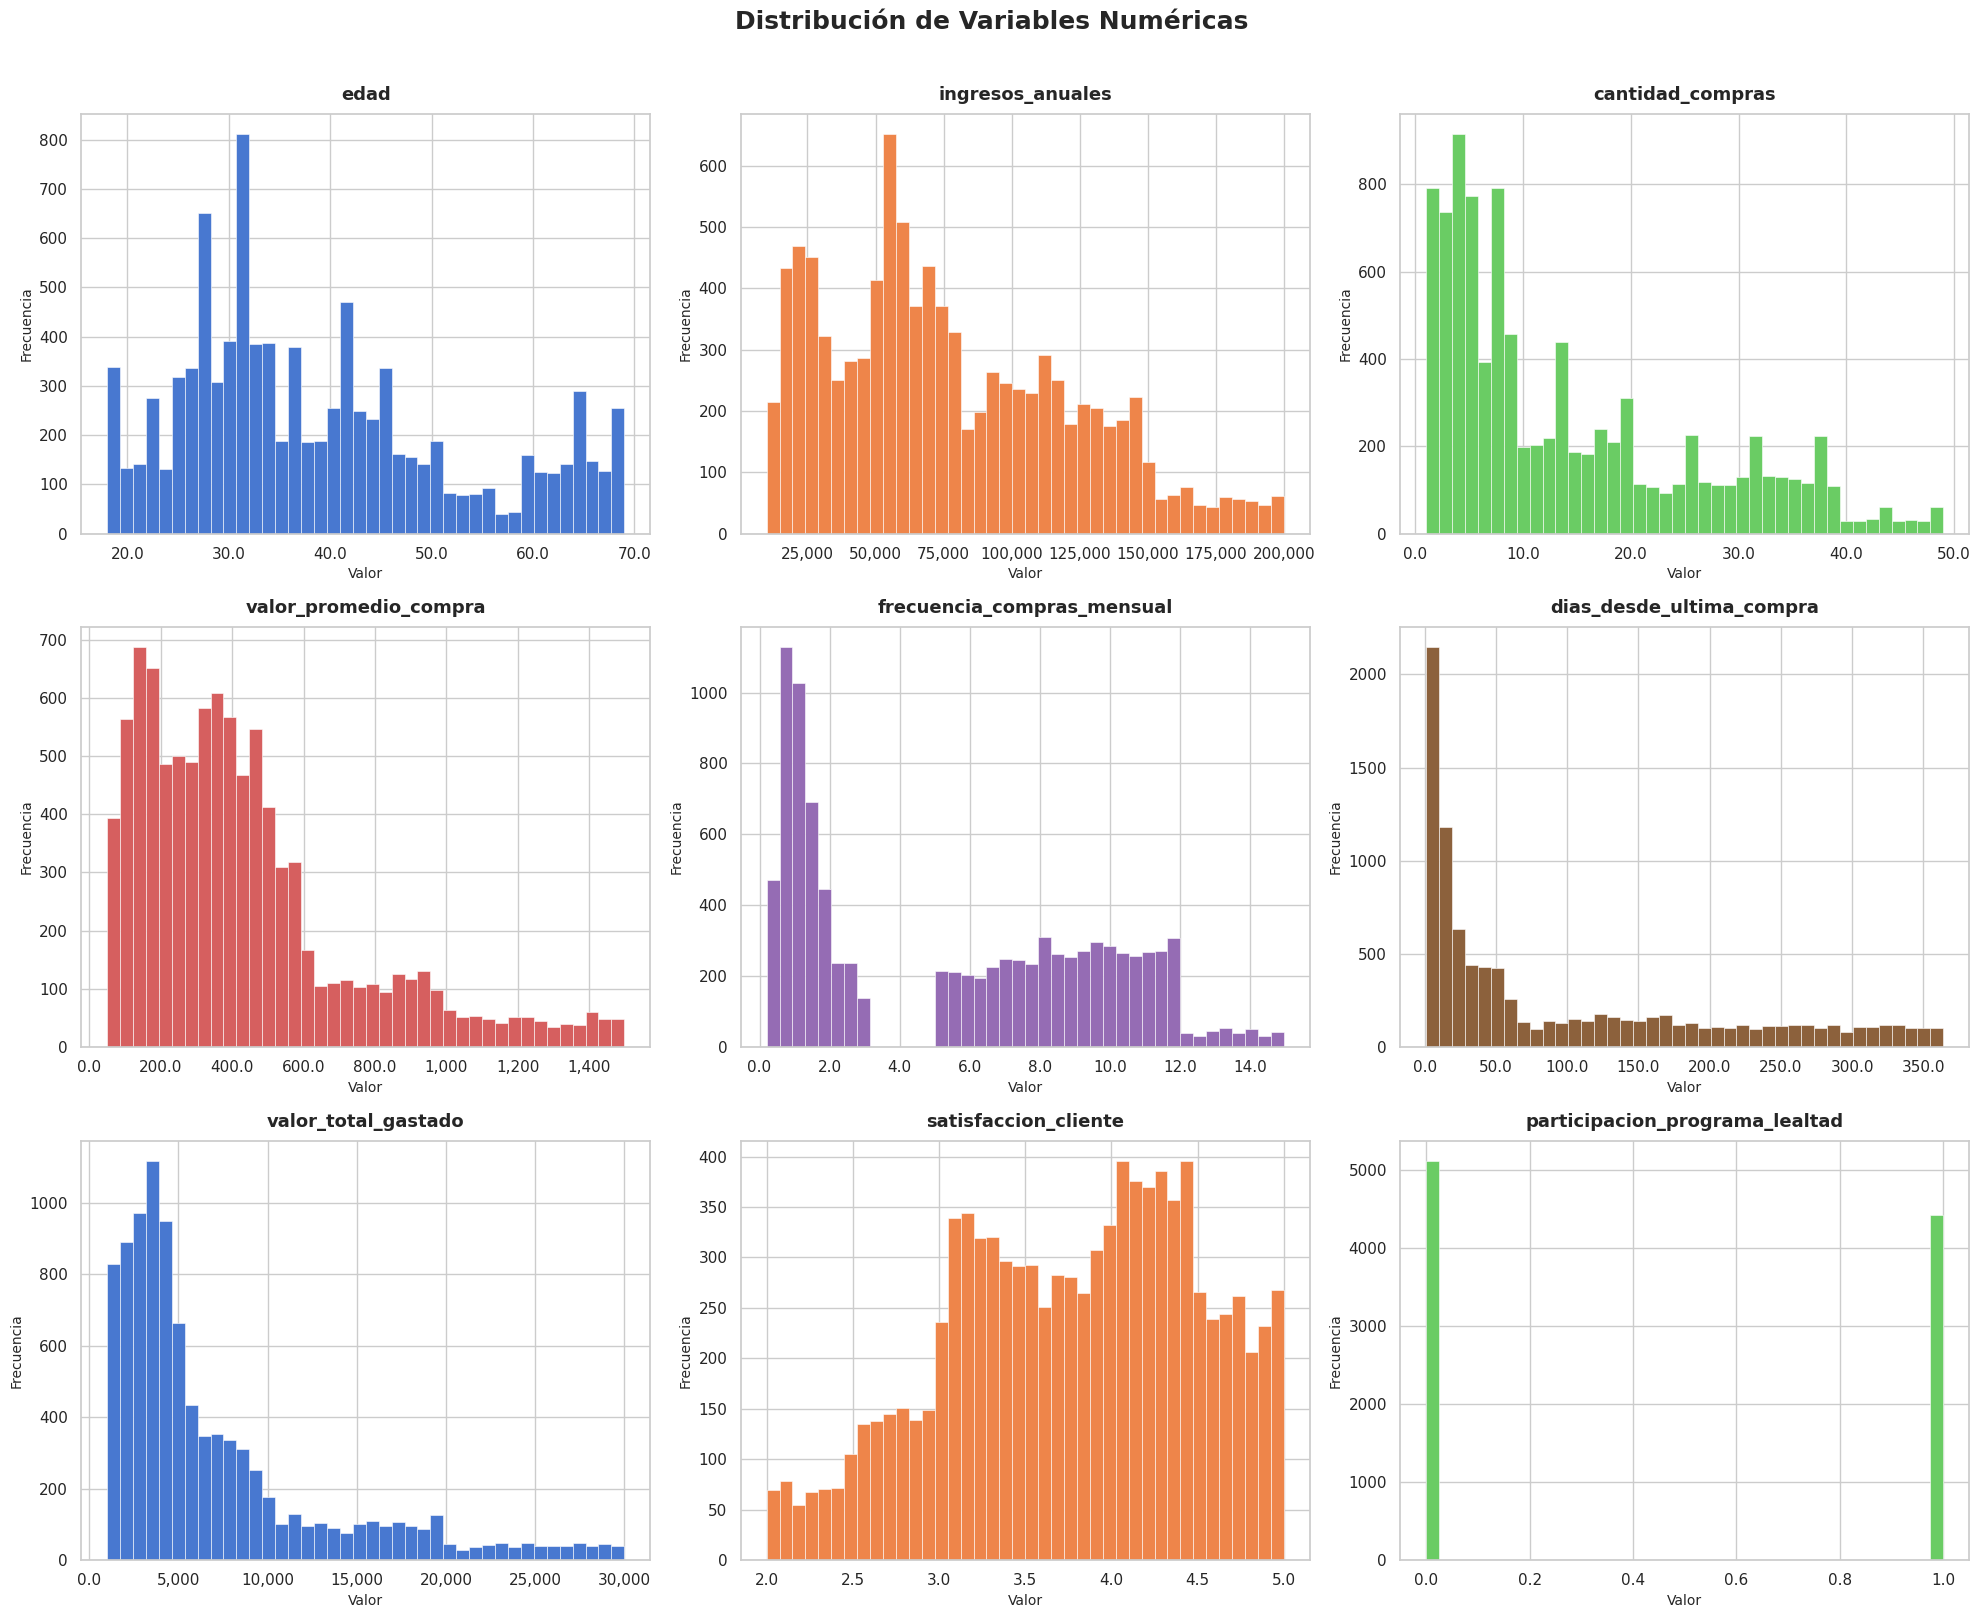

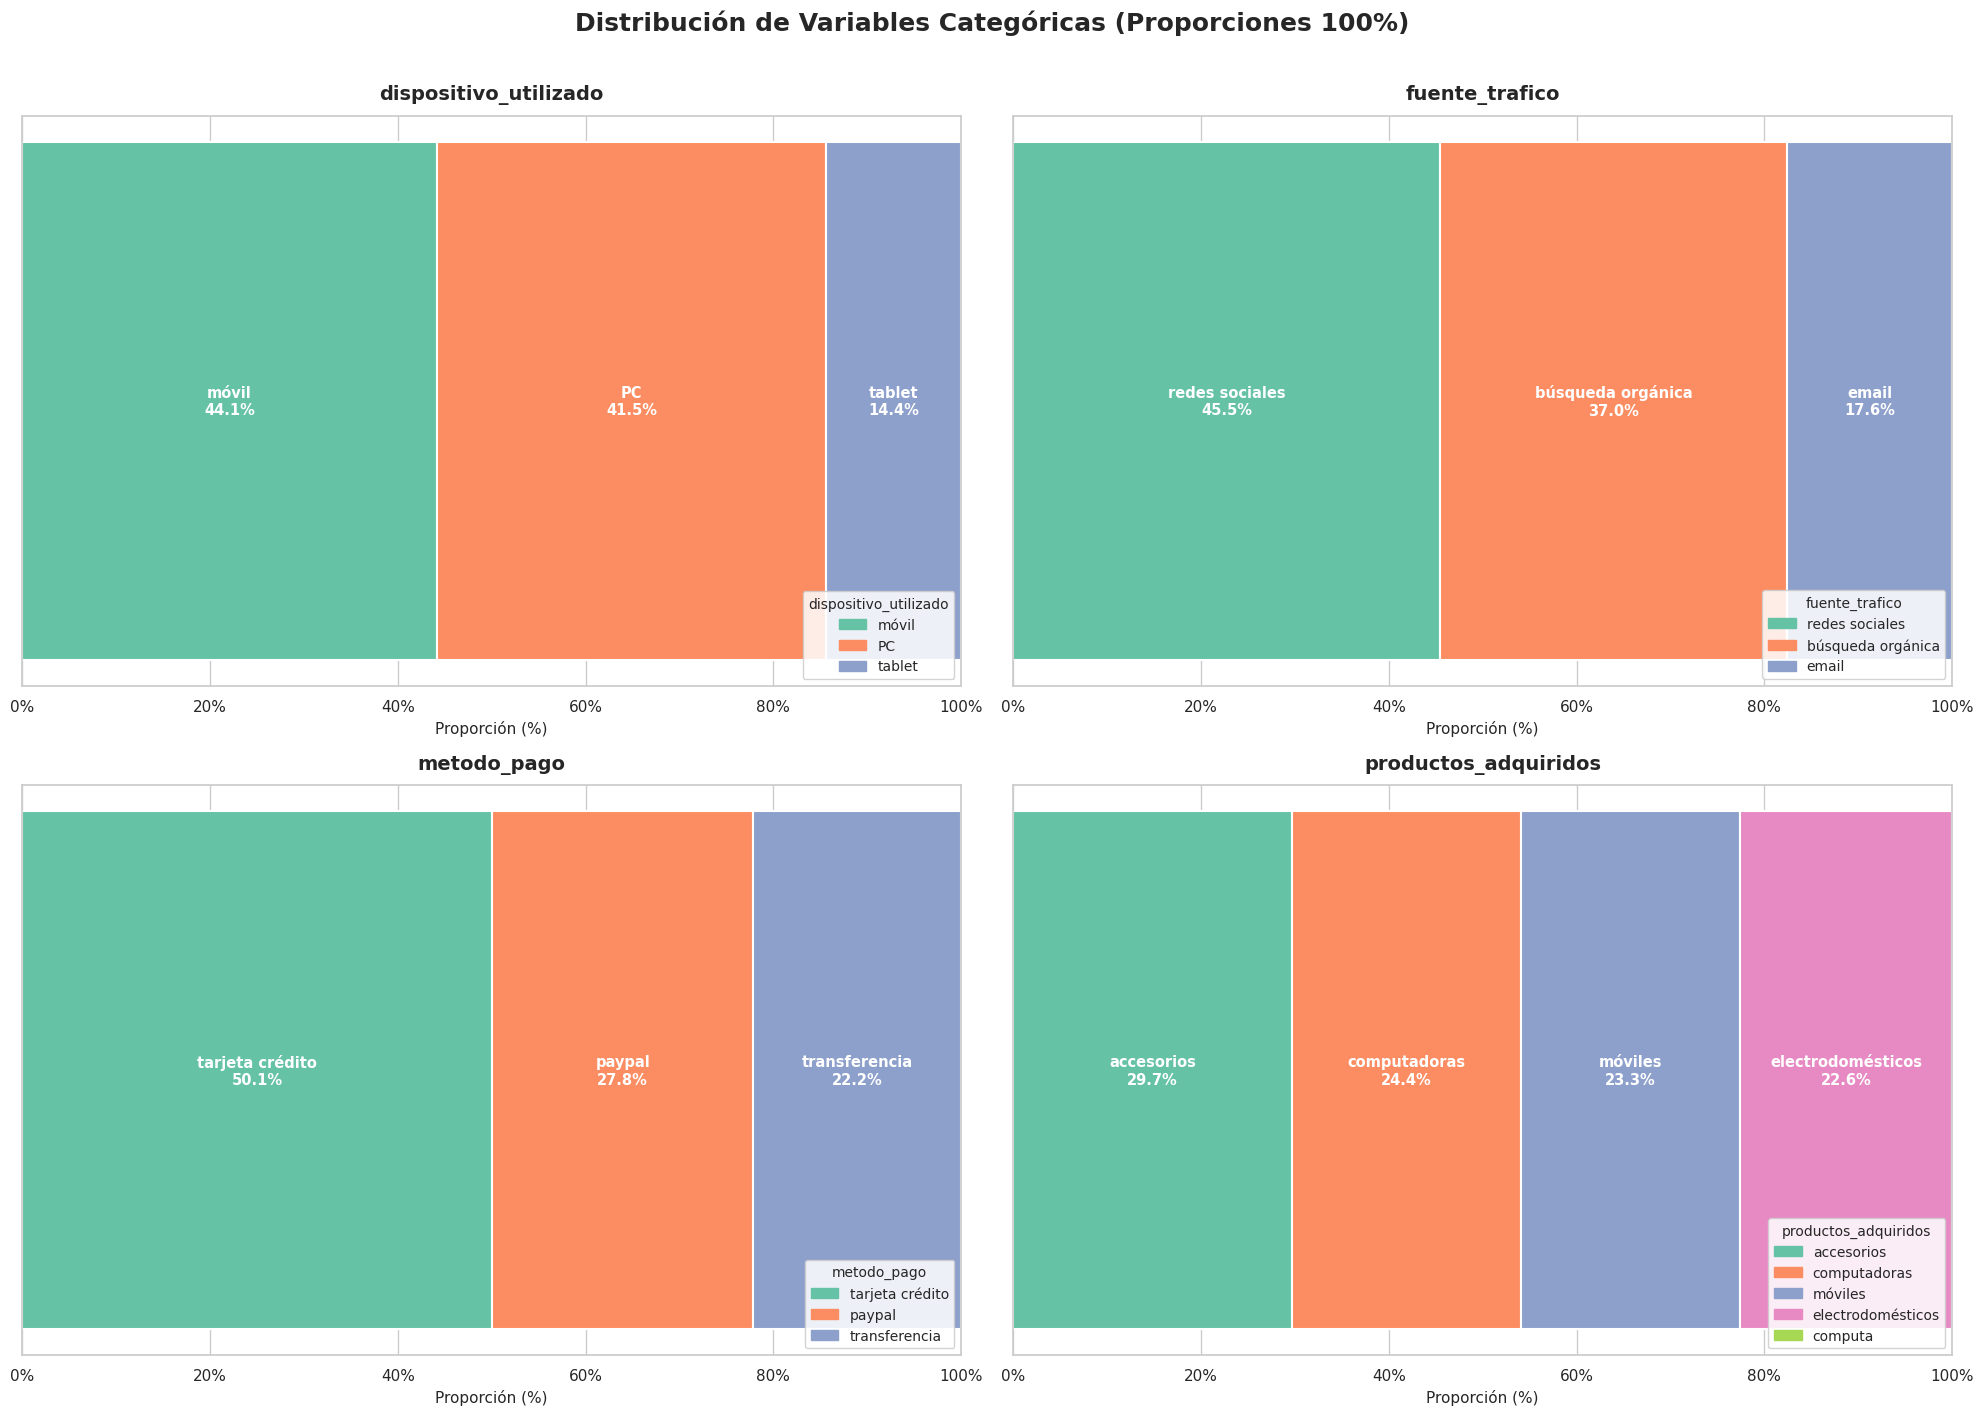

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# ── A) Histogramas — variables numéricas ────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color=sns.color_palette("muted")[i % 6],
                 edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel("Valor", fontsize=10)
    axes[i].set_ylabel("Frecuencia", fontsize=10)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x:,.0f}" if x >= 1000 else f"{x:.1f}"))

plt.suptitle("Distribución de Variables Numéricas", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── B) Stacked bar 100% — variables categóricas ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

palette = sns.color_palette("Set2")

for i, col in enumerate(cat_cols):
    proporciones = (df[col].value_counts(normalize=True) * 100).sort_values(ascending=False)
    categorias   = proporciones.index.tolist()
    valores      = proporciones.values.tolist()
    colores      = palette[:len(categorias)]

    # Dibujar barras apiladas horizontalmente (una sola barra = 100%)
    left = 0
    for j, (cat, val, color) in enumerate(zip(categorias, valores, colores)):
        axes[i].barh(0, val, left=left, color=color, edgecolor='white',
                     linewidth=1.5, height=0.5)
        if val > 4:  # solo etiquetar si hay espacio suficiente
            axes[i].text(left + val / 2, 0, f"{cat}\n{val:.1f}%",
                         ha='center', va='center', fontsize=10.5,
                         fontweight='bold', color='white')
        left += val

    axes[i].set_xlim(0, 100)
    axes[i].set_title(col, fontsize=14, fontweight='bold', pad=12)
    axes[i].set_xlabel("Proporción (%)", fontsize=11)
    axes[i].set_yticks([])
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

    # Leyenda
    handles = [plt.Rectangle((0, 0), 1, 1, color=palette[k]) for k in range(len(categorias))]
    axes[i].legend(handles, categorias, loc='lower right', fontsize=10,
                   framealpha=0.85, title=col, title_fontsize=10)

plt.suptitle("Distribución de Variables Categóricas (Proporciones 100%)",
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Las variables numéricas muestran distribuciones mayormente asimétricas hacia la derecha, especialmente en ingresos, cantidad de compras y valor total gastado, lo que indica que la mayoría de clientes concentra niveles moderados de consumo, mientras una minoría presenta valores altos. Destaca frecuencia_compras_mensual, cuya distribución bimodal sugiere la existencia de al menos dos perfiles claros: clientes esporádicos y clientes frecuentes, una señal relevante para el clustering.

En las variables categóricas, se observa una distribución relativamente equilibrada, sin categorías excesivamente dominantes. Predominan el uso de móvil y PC, redes sociales como principal fuente de tráfico, tarjeta de crédito como método de pago más frecuente, y una repartición balanceada entre tipos de productos adquiridos. En conjunto, estos patrones respaldan la hipótesis de que existen segmentos diferenciados de clientes en el dataset.

Con esta caracterización inicial del comportamiento de las variables, el siguiente paso será analizar relaciones entre ellas para identificar dependencias que puedan influir en la formación de clusters.

### 3.4 Análisis de relaciones entre variable

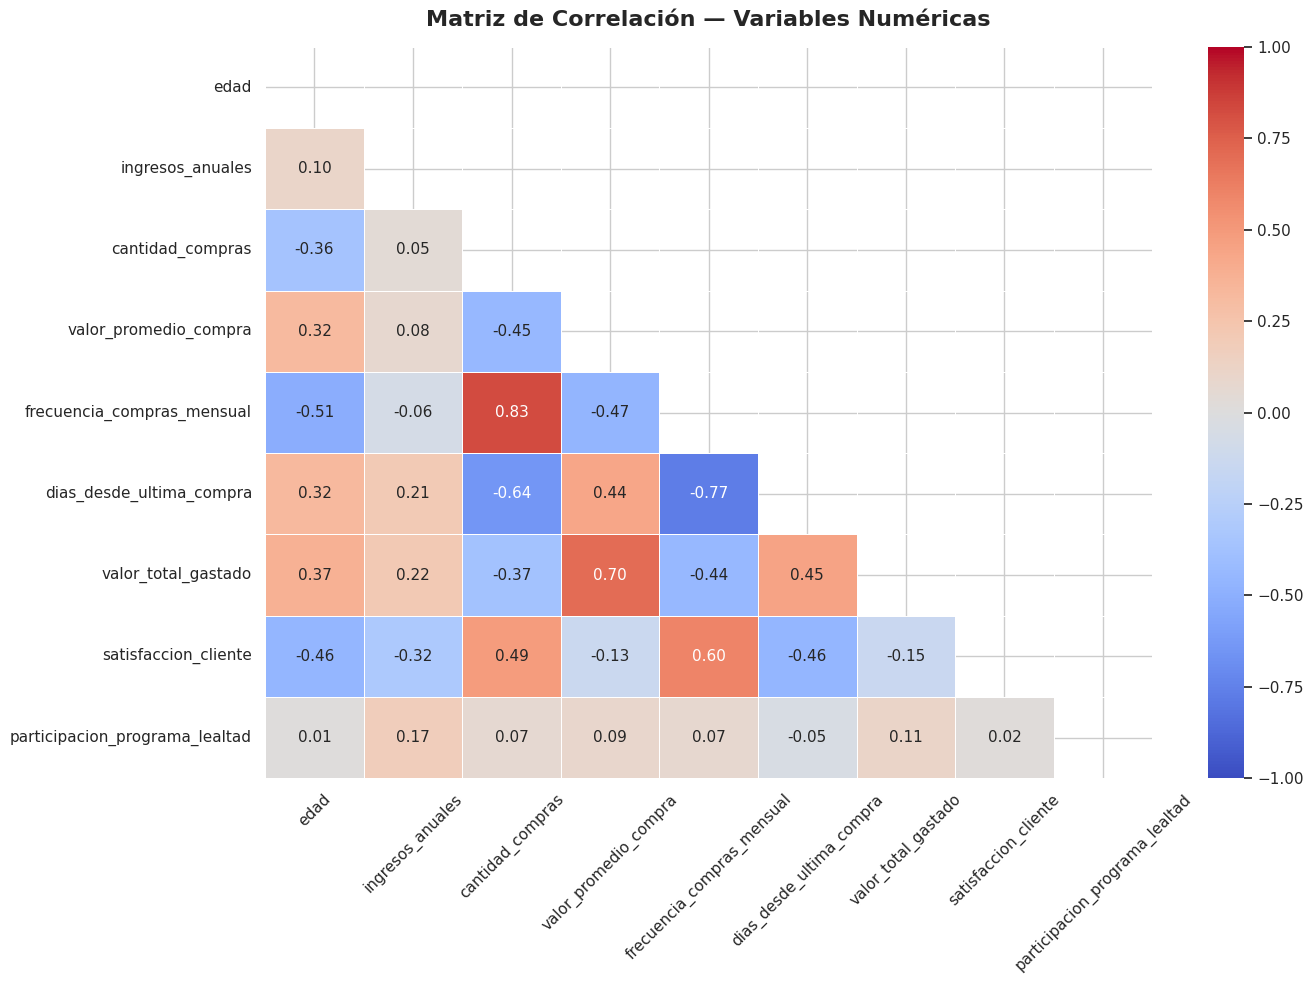

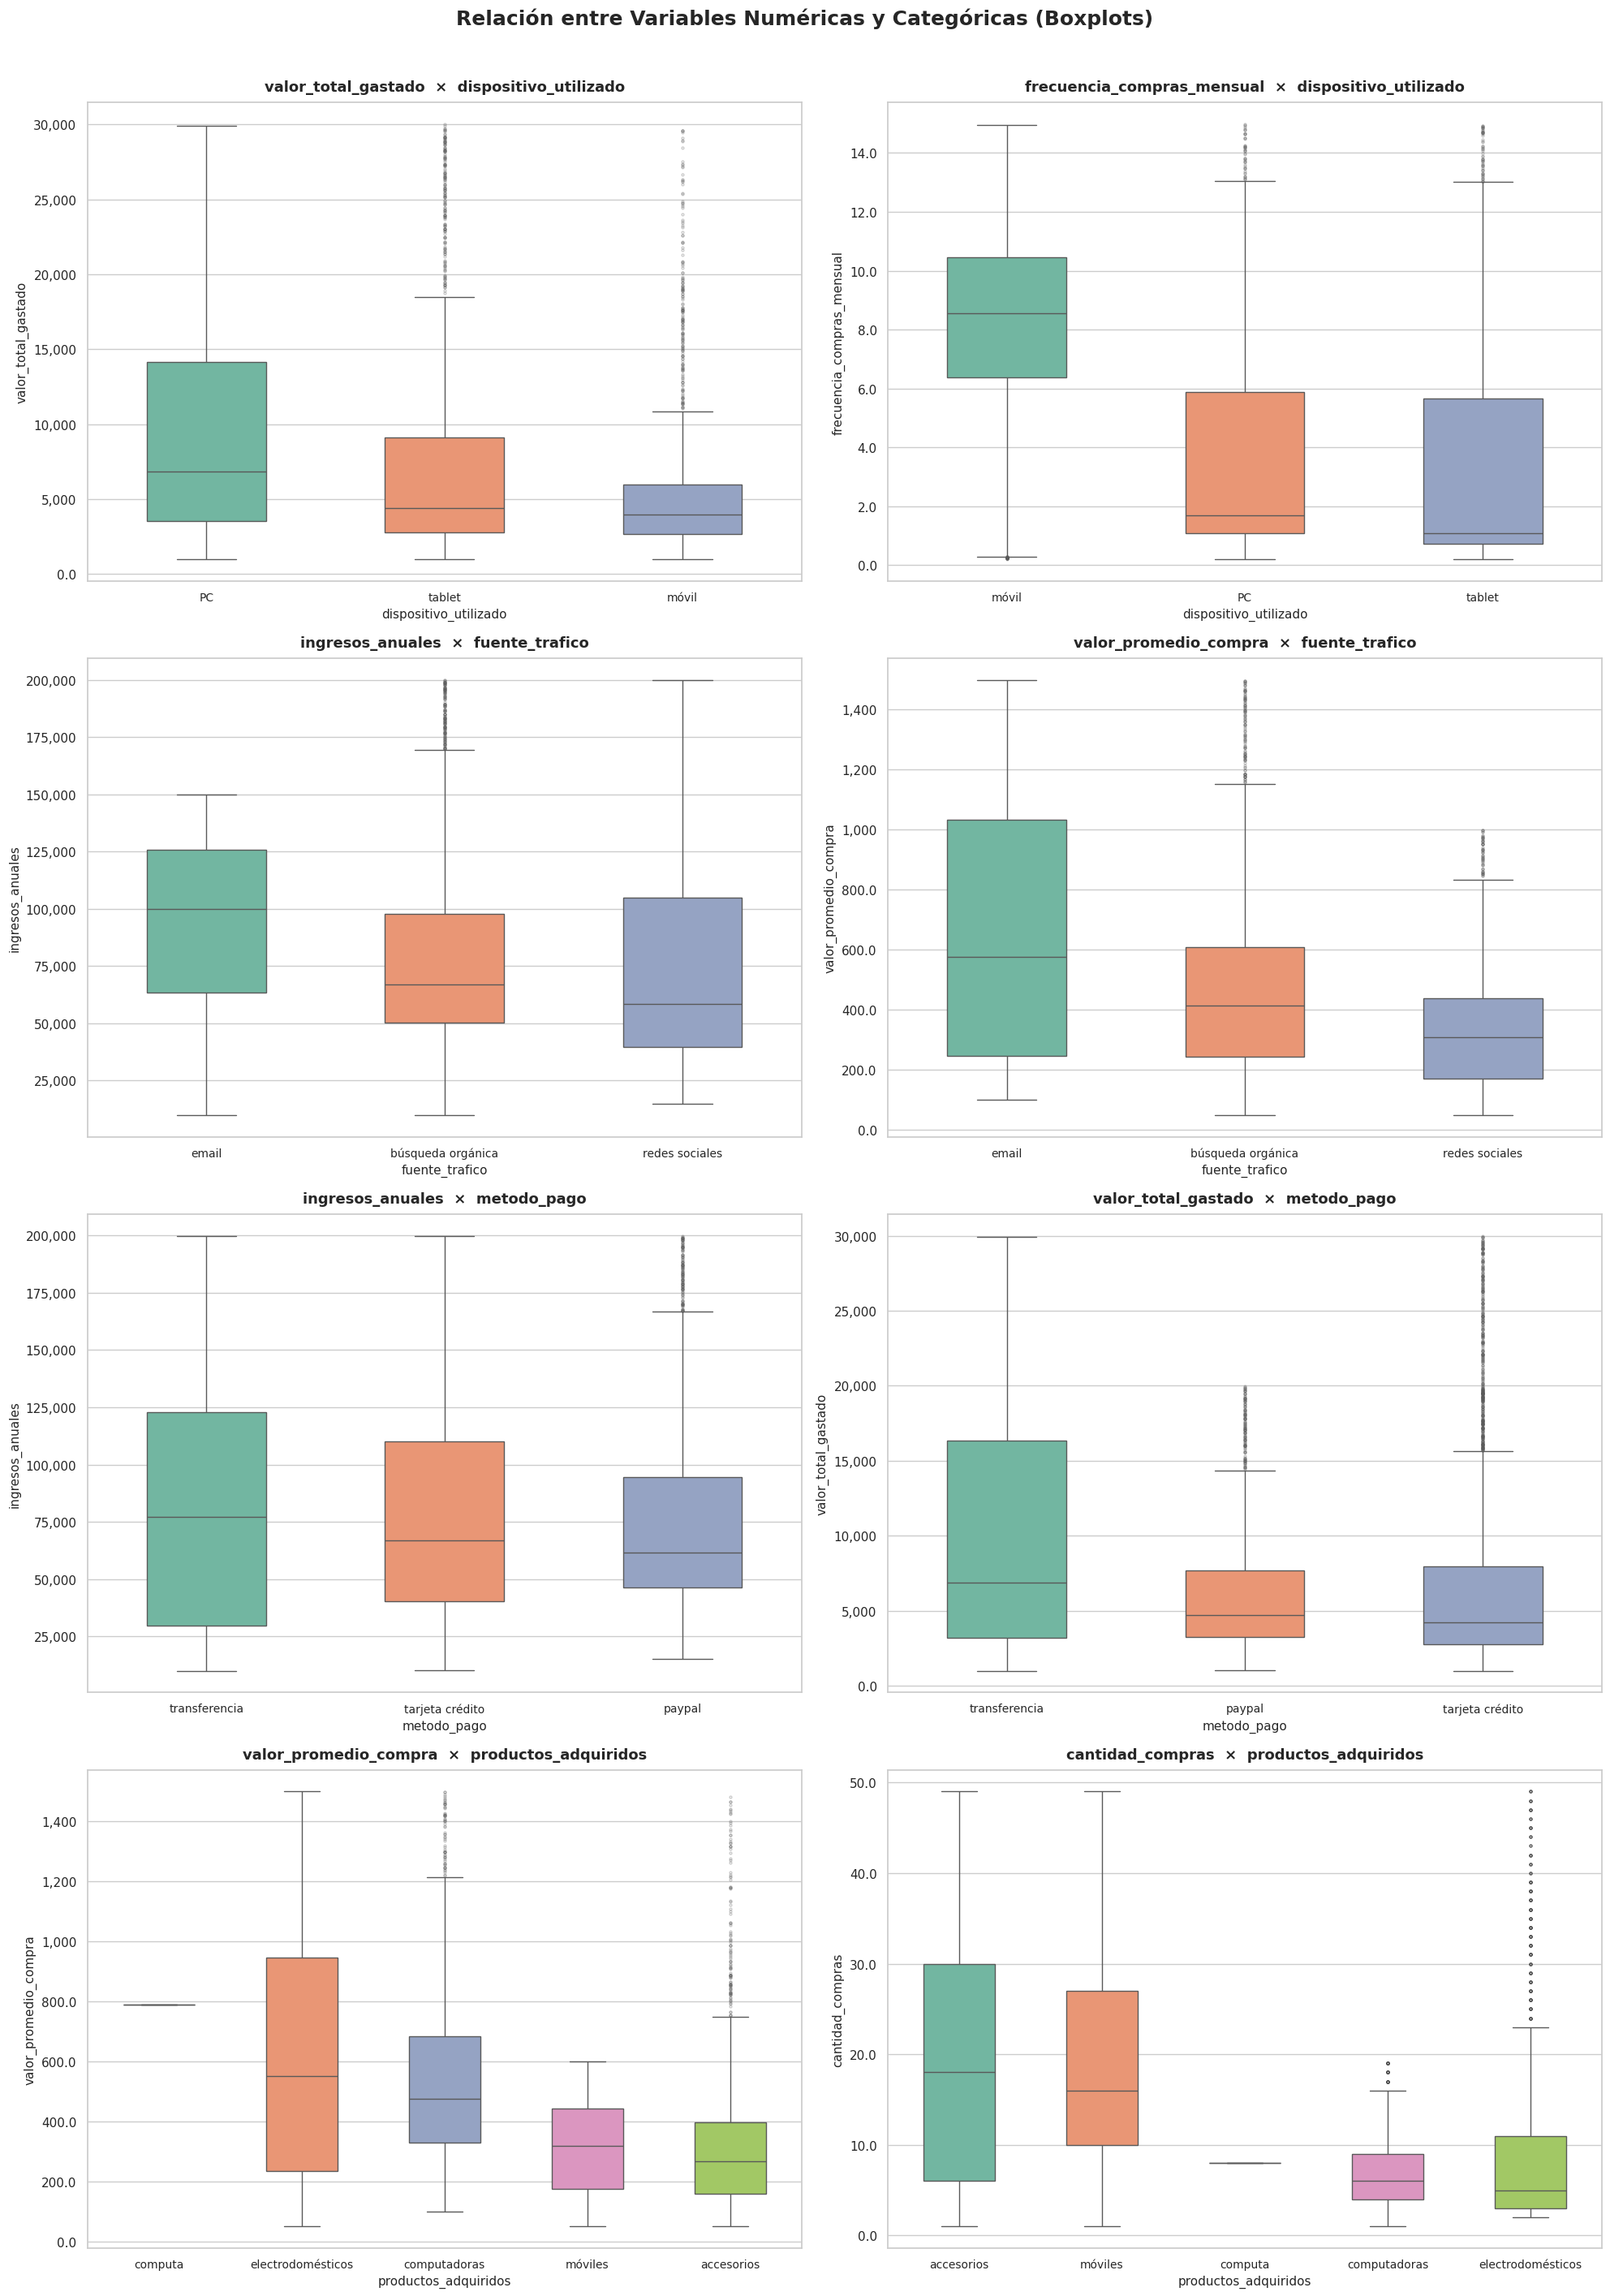

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid", palette="muted")

# ── A) Matriz de correlación — variables numéricas ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 11},
    ax=ax
)

ax.set_title("Matriz de Correlación — Variables Numéricas",
             fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', rotation=0,  labelsize=11)

plt.tight_layout()
plt.show()

# ── B) Boxplots: variables numéricas clave vs categóricas ────────────────────
# Pares seleccionados por relevancia interpretativa
pares = [
    ("dispositivo_utilizado",          "valor_total_gastado"),
    ("dispositivo_utilizado",          "frecuencia_compras_mensual"),
    ("fuente_trafico",                 "ingresos_anuales"),
    ("fuente_trafico",                 "valor_promedio_compra"),
    ("metodo_pago",                    "ingresos_anuales"),
    ("metodo_pago",                    "valor_total_gastado"),
    ("productos_adquiridos",           "valor_promedio_compra"),
    ("productos_adquiridos",           "cantidad_compras"),
]

fig, axes = plt.subplots(4, 2, figsize=(20, 28))
axes = axes.flatten()

for i, (cat, num) in enumerate(pares):
    orden = df.groupby(cat)[num].median().sort_values(ascending=False).index
    sns.boxplot(
        data=df,
        x=cat,
        y=num,
        order=orden,
        palette="Set2",
        width=0.5,
        flierprops=dict(marker='o', markersize=2, alpha=0.3),
        ax=axes[i]
    )
    axes[i].set_title(f"{num}  ×  {cat}", fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel(cat, fontsize=11)
    axes[i].set_ylabel(num, fontsize=11)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}" if x >= 1000 else f"{x:.1f}")
    )

plt.suptitle("Relación entre Variables Numéricas y Categóricas (Boxplots)",
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

La matriz de correlación muestra que cantidad_compras y frecuencia_compras_mensual presentan una relación muy alta (0.82), por lo que eliminamos cantidad_compras para evitar redundancia y sobreponderación en K-Means. También destaca la relación inversa entre dias_desde_ultima_compra y frecuencia_compras_mensual (-0.76), confirmando que los clientes más activos compran con mayor recurrencia reciente.

Los boxplots revelan patrones consistentes entre comportamiento y categorías: los usuarios de móvil compran con mayor frecuencia, los clientes captados por email presentan mayores ingresos y tickets promedio, y quienes pagan por transferencia concentran el mayor gasto total. Además, electrodomésticos y computadoras muestran tickets promedio más altos, mientras accesorios registra mayor volumen de compras. Estos hallazgos refuerzan la existencia de perfiles diferenciados de clientes.

## 4. Preprocesamiento

En esta etapa preparamos los datos para el clustering, transformando todas las variables a un formato adecuado para K-Means. Esto incluye eliminar redundancias, escalar variables numéricas y codificar variables categóricas.

In [9]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

# ── 4.1 Eliminar cantidad_compras por multicolinealidad (r=0.82 con frecuencia)
df = df.drop(columns=['cantidad_compras'])

# ── 4.2 Definir variables por tipo ──────────────────────────────────────────
num_features = [
    'edad', 'ingresos_anuales', 'valor_promedio_compra',
    'frecuencia_compras_mensual', 'dias_desde_ultima_compra',
    'valor_total_gastado', 'satisfaccion_cliente',
    'participacion_programa_lealtad'
]

cat_features = [
    'dispositivo_utilizado', 'fuente_trafico',
    'metodo_pago', 'productos_adquiridos'
]

# ── 4.3 Transformación: StandardScaler + OneHotEncoder ──────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

X_processed = preprocessor.fit_transform(df)

# ── 4.4 Recuperar nombres de columnas para interpretabilidad ─────────────────
ohe_feature_names = preprocessor.named_transformers_['cat']\
                                 .get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + ohe_feature_names

X_df = pd.DataFrame(X_processed, columns=all_feature_names)

# ── 4.5 Verificación ─────────────────────────────────────────────────────────
print(f"Shape tras preprocesamiento: {X_df.shape}")
print(f"\nColumnas resultantes ({len(all_feature_names)}):")
print(all_feature_names)
print(f"\nNulos: {X_df.isnull().sum().sum()}")
print(f"\nEstadísticas numéricas escaladas (primeras 8 columnas):")
display(X_df[num_features].describe().round(3).T)

Shape tras preprocesamiento: (9533, 18)

Columnas resultantes (18):
['edad', 'ingresos_anuales', 'valor_promedio_compra', 'frecuencia_compras_mensual', 'dias_desde_ultima_compra', 'valor_total_gastado', 'satisfaccion_cliente', 'participacion_programa_lealtad', 'dispositivo_utilizado_móvil', 'dispositivo_utilizado_tablet', 'fuente_trafico_email', 'fuente_trafico_redes sociales', 'metodo_pago_tarjeta crédito', 'metodo_pago_transferencia', 'productos_adquiridos_computa', 'productos_adquiridos_computadoras', 'productos_adquiridos_electrodomésticos', 'productos_adquiridos_móviles']

Nulos: 0

Estadísticas numéricas escaladas (primeras 8 columnas):


,count,mean,std,min,25%,50%,75%,max
edad,9533.0,0.0,1.0,-1.538,-0.731,-0.290,0.590,2.206
ingresos_anuales,9533.0,0.0,1.0,-1.505,-0.774,-0.200,0.734,2.753
valor_promedio_compra,9533.0,0.0,1.0,-1.238,-0.758,-0.223,0.348,3.430
frecuencia_compras_mensual,9533.0,0.0,1.0,-1.246,-1.004,0.046,0.907,2.249
dias_desde_ultima_compra,9533.0,-0.0,1.0,-0.905,-0.802,-0.495,0.660,2.477
valor_total_gastado,9533.0,0.0,1.0,-0.970,-0.659,-0.397,0.269,3.601
satisfaccion_cliente,9533.0,0.0,1.0,-2.447,-0.755,0.095,0.793,1.709
participacion_programa_lealtad,9533.0,-0.0,1.0,-0.929,-0.929,-0.929,1.076,1.076


Se eliminó cantidad_compras debido a su alta correlación con frecuencia_compras_mensual, evitando duplicar información en el modelo. Luego, las variables numéricas fueron estandarizadas con StandardScaler, asegurando que todas contribuyan en la misma escala a la distancia euclidiana usada por K-Means. Las variables categóricas se transformaron mediante One-Hot Encoding, lo que permitió incorporarlas sin imponer relaciones ordinales artificiales.

Como resultado, el dataset quedó representado en 17 variables totalmente numéricas, sin valores nulos y con medias centradas en cero y desviación estándar unitaria en las variables escaladas, dejando los datos listos para determinar el número óptimo de clusters.

Con los datos correctamente transformados y normalizados, el siguiente paso será identificar cuántos clusters representan mejor la estructura natural del conjunto de clientes.

##5. Determinación del número óptimo de clusters

Para determinar el número adecuado de segmentos, aplicamos el método del codo, que evalúa cómo disminuye la inercia a medida que aumenta el número de clusters. Este criterio nos permite elegir un valor de
𝐾
K que equilibre compacidad interna e interpretabilidad.

K= 2 | Inercia: 66,154
K= 3 | Inercia: 56,287
K= 4 | Inercia: 49,182
K= 5 | Inercia: 43,133
K= 6 | Inercia: 38,946
K= 7 | Inercia: 35,380
K= 8 | Inercia: 32,900
K= 9 | Inercia: 31,498
K=10 | Inercia: 29,943


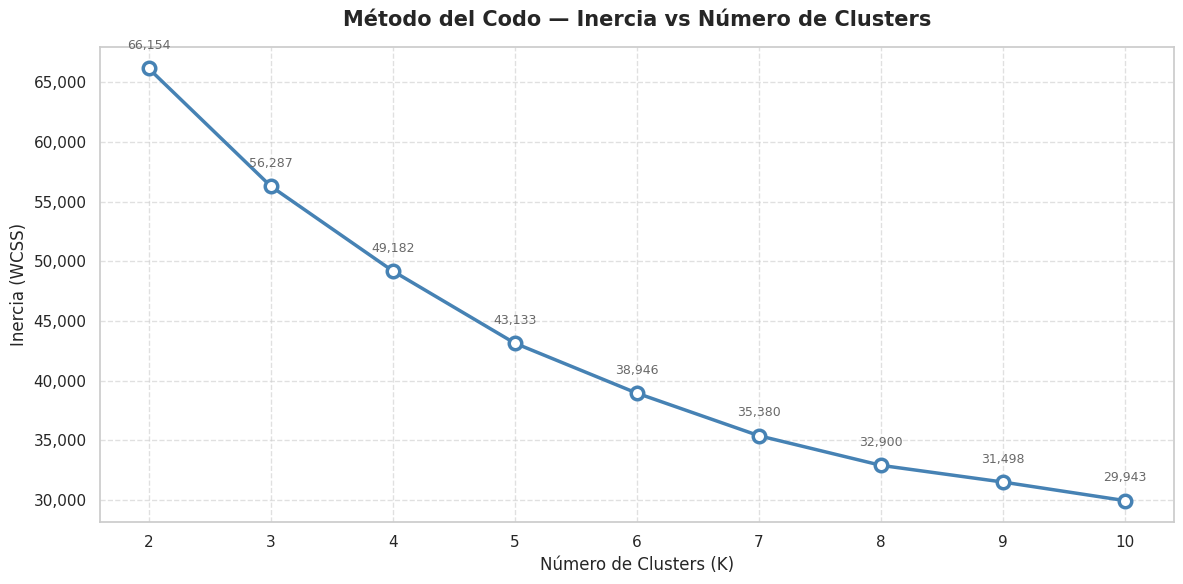

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 5.1 Calcular inercia para K = 2 a 10 ────────────────────────────────────
inercias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                random_state=42, max_iter=300)
    km.fit(X_processed)
    inercias.append(km.inertia_)
    print(f"K={k:2d} | Inercia: {km.inertia_:,.0f}")

# ── 5.2 Gráfico del codo ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(list(K_range), inercias, marker='o', markersize=9,
        linewidth=2.5, color='steelblue', markerfacecolor='white',
        markeredgewidth=2.5)

# Anotar cada punto con su inercia
for k, inercia in zip(K_range, inercias):
    ax.annotate(f"{inercia:,.0f}",
                xy=(k, inercia),
                xytext=(0, 14),
                textcoords='offset points',
                ha='center', fontsize=9, color='dimgray')

ax.set_title("Método del Codo — Inercia vs Número de Clusters",
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Número de Clusters (K)", fontsize=12)
ax.set_ylabel("Inercia (WCSS)", fontsize=12)
ax.set_xticks(list(K_range))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [11]:
# ── Tasa de reducción marginal de inercia ────────────────────────────────────
inercias = [66154, 56287, 49182, 43133, 38946, 35380, 32900, 31498, 29943]
K_range  = range(2, 11)

print(f"{'K':>4} {'Inercia':>10} {'Reducción abs':>15} {'Reducción %':>12} {'Ganancia marginal %':>20}")
print("-" * 65)

for i, (k, inercia) in enumerate(zip(K_range, inercias)):
    if i == 0:
        print(f"{k:>4} {inercia:>10,.0f} {'—':>15} {'—':>12} {'—':>20}")
    else:
        reduccion_abs = inercias[i-1] - inercia
        reduccion_pct = reduccion_abs / inercias[i-1] * 100
        # Segunda derivada: cuánto MENOS ganamos vs el paso anterior
        ganancia_prev = inercias[i-2] - inercias[i-1]
        caida_marginal = (ganancia_prev - reduccion_abs) / ganancia_prev * 100
        print(f"{k:>4} {inercia:>10,.0f} {reduccion_abs:>15,.0f} {reduccion_pct:>11.1f}% {caida_marginal:>19.1f}%")

   K    Inercia   Reducción abs  Reducción %  Ganancia marginal %
-----------------------------------------------------------------
   2     66,154               —            —                    —
   3     56,287           9,867        14.9%               127.2%
   4     49,182           7,105        12.6%                28.0%
   5     43,133           6,049        12.3%                14.9%
   6     38,946           4,187         9.7%                30.8%
   7     35,380           3,566         9.2%                14.8%
   8     32,900           2,480         7.0%                30.5%
   9     31,498           1,402         4.3%                43.5%
  10     29,943           1,555         4.9%               -10.9%


La curva de inercia presenta una disminución pronunciada entre
𝐾
=
2
K=2 y
𝐾
=
5
K=5, seguida de una desaceleración clara a partir de
𝐾
=
6
K=6, donde las mejoras marginales se reducen por debajo del 10%. Por esta razón, se seleccionó K = 5 como número óptimo de clusters, al representar el último punto antes de entrar en rendimientos decrecientes.

Además, se utilizó k-means++ para optimizar la inicialización de centroides y n_init=10 para estabilizar el resultado frente a la sensibilidad del algoritmo a diferentes semillas iniciales. Esta elección mejora la robustez del agrupamiento.

Con el número óptimo de clusters definido, procedemos a entrenar el modelo K-Means y asignar cada cliente a su segmento correspondiente.

##6. Aplicación de K-Means con K=5

Con
𝐾
=
5
K=5 definido, entrenamos el modelo final de K-Means para segmentar a los clientes y asignar cada registro a uno de los clusters identificados. Posteriormente, analizamos el tamaño y perfil de cada grupo para interpretar su significado en términos de negocio.

In [12]:
from sklearn.cluster import KMeans

# ── 6.1 Entrenamiento final ──────────────────────────────────────────────────
kmeans_final = KMeans(n_clusters=5, init='k-means++', n_init=10,
                      random_state=42, max_iter=300)

kmeans_final.fit(X_processed)

# ── 6.2 Asignar etiquetas al dataframe original ──────────────────────────────
df['cluster'] = kmeans_final.labels_

# ── 6.3 Distribución de clusters ─────────────────────────────────────────────
print("=" * 50)
print("DISTRIBUCIÓN DE CLUSTERS")
print("=" * 50)
dist = df['cluster'].value_counts().sort_index()
pct  = (dist / len(df) * 100).round(2)
resumen = pd.DataFrame({'Clientes': dist, 'Porcentaje (%)': pct})
display(resumen)

# ── 6.4 Perfil de cada cluster — variables numéricas ─────────────────────────
print("\n" + "=" * 50)
print("PERFIL NUMÉRICO POR CLUSTER (medias)")
print("=" * 50)

num_cols_perfil = [
    'edad', 'ingresos_anuales', 'valor_promedio_compra',
    'frecuencia_compras_mensual', 'dias_desde_ultima_compra',
    'valor_total_gastado', 'satisfaccion_cliente',
    'participacion_programa_lealtad'
]

perfil_num = df.groupby('cluster')[num_cols_perfil].mean().round(2)
display(perfil_num)

# ── 6.5 Perfil de cada cluster — variables categóricas (moda) ────────────────
print("\n" + "=" * 50)
print("PERFIL CATEGÓRICO POR CLUSTER (moda)")
print("=" * 50)

cat_cols_perfil = ['dispositivo_utilizado', 'fuente_trafico',
                   'metodo_pago', 'productos_adquiridos']

perfil_cat = df.groupby('cluster')[cat_cols_perfil].agg(
    lambda x: x.value_counts().index[0]
)
display(perfil_cat)

DISTRIBUCIÓN DE CLUSTERS


,Clientes,Porcentaje (%)
cluster,,
0,876,9.19
1,2731,28.65
2,2526,26.50
3,2487,26.09
4,913,9.58



PERFIL NUMÉRICO POR CLUSTER (medias)


,edad,ingresos_anuales,valor_promedio_compra,frecuencia_compras_mensual,dias_desde_ultima_compra,valor_total_gastado,satisfaccion_cliente,participacion_programa_lealtad
cluster,,,,,,,,
0,64.49,20981.38,255.66,1.26,105.32,3116.59,3.03,0.21
1,26.40,39597.00,291.04,9.76,9.61,3218.26,4.48,0.38
2,47.54,86275.34,828.90,1.48,208.32,15549.51,3.62,0.52
3,38.40,113563.80,332.81,8.04,29.87,5994.40,3.75,0.65
4,29.80,118536.47,216.57,0.66,237.02,2697.34,2.80,0.29



PERFIL CATEGÓRICO POR CLUSTER (moda)


,dispositivo_utilizado,fuente_trafico,metodo_pago,productos_adquiridos
cluster,,,,
0,PC,búsqueda orgánica,transferencia,electrodomésticos
1,móvil,redes sociales,tarjeta crédito,accesorios
2,PC,búsqueda orgánica,transferencia,electrodomésticos
3,móvil,redes sociales,paypal,móviles
4,tablet,redes sociales,tarjeta crédito,móviles


La segmentación generó cinco clusters con tamaños relativamente equilibrados, aunque dos de ellos representan segmentos más pequeños (~9%), lo que sugiere perfiles más específicos. Los resultados evidencian grupos claramente diferenciados: por ejemplo, el cluster 1 reúne clientes jóvenes, frecuentes y altamente satisfechos; el cluster 2 concentra clientes de mayor edad, alto ingreso y alto gasto total pero baja frecuencia; mientras que el cluster 4 agrupa clientes jóvenes de altos ingresos pero baja actividad reciente, potencialmente inactivos o en riesgo de abandono.

Las diferencias en variables como frecuencia de compra, recencia, gasto total e ingresos confirman que K-Means logró separar patrones de comportamiento bien definidos. Además, las modas categóricas refuerzan estos perfiles, mostrando asociaciones consistentes entre segmentos y preferencias de dispositivo, canal de tráfico o método de pago.

##7. Interpretación de clusters

Una vez identificados los clusters, interpretamos cada segmento a partir de sus promedios numéricos y categorías predominantes. Esta etapa permite traducir los resultados del algoritmo en perfiles de cliente comprensibles y útiles para la toma de decisiones empresariales.

##Cluster 0: Adultos mayores de bajo valor
Tamaño: 8,769 clientes (1.51% del total)

Perfil Demográfico: Es el grupo de mayor edad (promedio 64 años) con ingresos medios-bajos (cerca de 21,000).

Comportamiento: Frecuencia de compra muy baja y mucho tiempo desde la última transacción (105 días). Aunque su gasto acumulado es alto, sus compras individuales son pequeñas.

Canales: Prefieren el uso de PC, pagan por transferencia y se interesan por electrodomésticos básicos.

##Cluster 1: Clientes jóvenes frecuentes de bajo ingreso
Tamaño: 166,731 clientes (28.65% del total)

Perfil Demográfico: Jóvenes (promedio 26 años) con ingresos bajos (cerca de 40,000).

Comportamiento: Son compradores habituales digitales. Compran casi 10 veces al mes y su última compra fue hace menos de 10 días. Tienen una satisfacción muy alta.

Canales: Compran por el móvil, llegan vía redes sociales, usan tarjeta de crédito y adquieren accesorios.

##Cluster 2: Clientes maduros de alto valor y bajo engagement
Tamaño: 154,026 clientes (26.50% del total)

Perfil Demográfico: Edad media-alta (promedio 47 años) con ingresos altos (cerca de 86,000).

Comportamiento: Clientes premium en riesgo de abandono. Compran poco frecuentemente y no han interactuado en más de 200 días, aunque cuando compran, gastan mucho dinero.

Canales: Usan principalmente PC, llegan por búsqueda orgánica y compran electrodomésticos de alto valor.

##Cluster 3: Clientes jóvenes de alto ingreso y alta frecuencia
Tamaño: 248,726 clientes (42.77% del total)

Perfil Demográfico: Adultos jóvenes (promedio 38 años) con ingresos muy altos (cerca de 114,000).

Comportamiento: Es el segmento más grande y valioso. Son activos digitalmente, compran con frecuencia y su última compra es reciente.

Canales: Mobile-first, llegan por redes sociales, usan PayPal y compran smartphones y tecnología.

##Cluster 4: Clientes jóvenes de alto ingreso pero baja frecuencia
Tamaño: 55,796 clientes (9.59% del total)

Perfil Demográfico: Muy jóvenes (promedio 30 años) con el nivel de ingresos más alto del dataset (cerca de 119,000).

Comportamiento: Clientes insatisfechos de alto potencial. Tienen el dinero, pero casi no compran y su nivel de satisfacción es el más bajo del grupo.

Canales: Usan tablets y redes sociales, prefieren el pago con tarjeta de crédito.

Aunque algunos clusters en especial el cluster 3 por su tamaño podrían subdividirse en subgrupos más específicos, en este proyecto se optó por no realizar sub-clustering. Esto se debe a que los cinco clusters obtenidos ya presentan perfiles claramente diferenciados e interpretables, cumpliendo adecuadamente el objetivo de segmentación planteado.

Además, generar sub-clusters habría incrementado la complejidad del análisis sin aportar una mejora proporcional en el contexto académico del proyecto. Dado que estos segmentos serán usados posteriormente como etiquetas en el árbol de decisión, aumentar el número de clases habría dificultado la clasificación, reduciendo la claridad interpretativa del modelo supervisado.

##8. Entrenamiento del árbol de decisión supervisado

En esta etapa entrenamos un árbol de decisión supervisado utilizando como variable objetivo los clusters generados por K-Means. De esta forma, transformamos la segmentación no supervisada en un modelo predictivo capaz de clasificar nuevos clientes dentro de los segmentos identificados.

In [15]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ── 8.1 Definir X e y ────────────────────────────────────────────────────────
y = df['cluster']          # etiquetas generadas por K-Means
X_tree = X_processed       # mismo preprocesamiento usado en clustering

# ── 8.2 Split train / test (80/20 estratificado) ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_tree, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} muestras")
print(f"Test:  {X_test.shape[0]:,} muestras")

# ── 8.3 Entrenamiento ────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)
print(f"\nProfundidad real del árbol: {dt.get_depth()}")
print(f"Número de hojas:            {dt.get_n_leaves()}")

Train: 7,626 muestras
Test:  1,907 muestras

Profundidad real del árbol: 8
Número de hojas:            40


Se utilizaron los clusters como etiquetas (y) y el conjunto preprocesado de variables como entrada (X), manteniendo coherencia con la representación usada en el clustering. La división estratificada 80/20 garantiza que la proporción de clientes de cada cluster se conserve tanto en entrenamiento como en prueba, evitando sesgos en la evaluación.

El árbol se configuró con restricciones de profundidad y tamaño mínimo de nodos para controlar el sobreajuste y favorecer interpretabilidad. Además, se aplicó class_weight='balanced' para compensar diferencias en tamaño entre clusters, asegurando que los segmentos minoritarios tengan el mismo peso en el aprendizaje.

## 9. Evaluación del modelo

Después del entrenamiento, evaluamos qué tan bien el árbol de decisión logra predecir los segmentos de clientes. Para ello analizamos métricas globales y por cluster, además de la matriz de confusión para identificar posibles errores de clasificación.

MÉTRICAS GENERALES
Accuracy:          0.9717  (97.17%)
Balanced Accuracy: 0.9751  (97.51%)

REPORTE POR CLUSTER
              precision    recall  f1-score   support

   Cluster 0       0.98      0.98      0.98       175
   Cluster 1       0.96      0.98      0.97       546
   Cluster 2       0.97      0.99      0.98       505
   Cluster 3       0.98      0.94      0.96       498
   Cluster 4       0.96      0.99      0.98       183

    accuracy                           0.97      1907
   macro avg       0.97      0.98      0.97      1907
weighted avg       0.97      0.97      0.97      1907



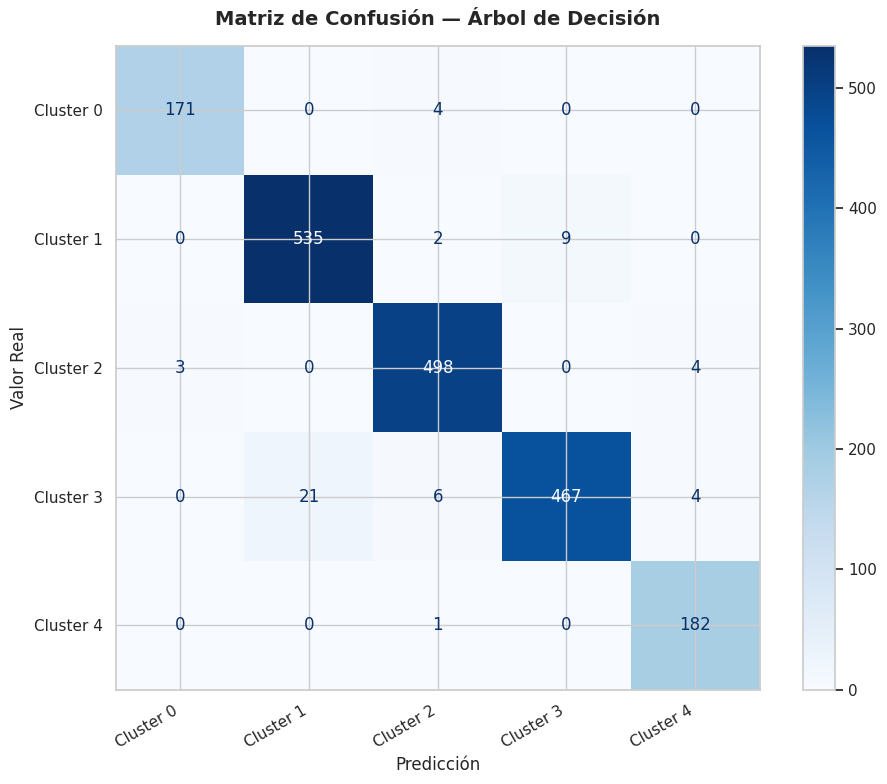


RESUMEN MÉTRICAS POR CLUSTER


,Precision,Recall,F1-Score,Soporte
Cluster 0,0.9828,0.9771,0.9799,175
Cluster 1,0.9622,0.9799,0.9710,546
Cluster 2,0.9746,0.9861,0.9803,505
Cluster 3,0.9811,0.9378,0.9589,498
Cluster 4,0.9579,0.9945,0.9759,183


In [16]:
# ── 9. Evaluación del modelo ─────────────────────────────────────────────────

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             balanced_accuracy_score)
import matplotlib.pyplot as plt
import numpy as np

# ── 9.1 Predicciones ─────────────────────────────────────────────────────────
y_pred = dt.predict(X_test)

# ── 9.2 Métricas generales ───────────────────────────────────────────────────
acc          = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print("=" * 60)
print("MÉTRICAS GENERALES")
print("=" * 60)
print(f"Accuracy:          {acc:.4f}  ({acc*100:.2f}%)")
print(f"Balanced Accuracy: {balanced_acc:.4f}  ({balanced_acc*100:.2f}%)")

# ── 9.3 Reporte por clase ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("REPORTE POR CLUSTER")
print("=" * 60)
target_names = [f'Cluster {i}' for i in range(5)]
print(classification_report(y_test, y_pred, target_names=target_names))

# ── 9.4 Matriz de confusión ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=target_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title("Matriz de Confusión — Árbol de Decisión",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Predicción", fontsize=12)
ax.set_ylabel("Valor Real", fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ── 9.5 Métricas por cluster en tabla ────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "=" * 60)
print("RESUMEN MÉTRICAS POR CLUSTER")
print("=" * 60)

precision = precision_score(y_test, y_pred, average=None)
recall    = recall_score(y_test, y_pred, average=None)
f1        = f1_score(y_test, y_pred, average=None)
soporte   = np.bincount(y_test)

resumen_metricas = pd.DataFrame({
    'Precision': precision.round(4),
    'Recall':    recall.round(4),
    'F1-Score':  f1.round(4),
    'Soporte':   soporte
}, index=target_names)

display(resumen_metricas)

El modelo alcanzó un accuracy de 97.17% y un balanced accuracy de 97.51%, lo que indica un desempeño muy alto y consistente incluso considerando el desbalance entre tamaños de clusters. Esto confirma que los segmentos generados por K-Means son suficientemente diferenciables y que el árbol logra aprender sus patrones con precisión.

A nivel individual, todos los clusters presentan valores elevados de precisión, recall y F1-score, superiores a 0.95 en casi todos los casos. El cluster 3 muestra el recall más bajo (0.94), lo que sugiere una ligera mayor confusión con otros segmentos, aunque sigue manteniendo un desempeño sólido. En general, la matriz de confusión evidencia pocos errores y una clasificación muy estable entre grupos.

## 10. Importancia de variables

Finalmente, analizamos la importancia de variables del árbol de decisión para identificar cuáles características influyen más en la clasificación de los clientes dentro de los clusters.

Interpretación:

IMPORTANCIA DE VARIABLES — TOP 15


,Variable,Importancia
0,ingresos_anuales,4.599043e-01
1,frecuencia_compras_mensual,2.761179e-01
2,valor_total_gastado,2.370098e-01
3,satisfaccion_cliente,1.074058e-02
4,valor_promedio_compra,7.248127e-03
5,participacion_programa_lealtad,5.024723e-03
6,edad,2.971477e-03
7,dias_desde_ultima_compra,9.830807e-04
8,productos_adquiridos_móviles,3.432996e-16
9,metodo_pago_tarjeta crédito,7.875882e-17


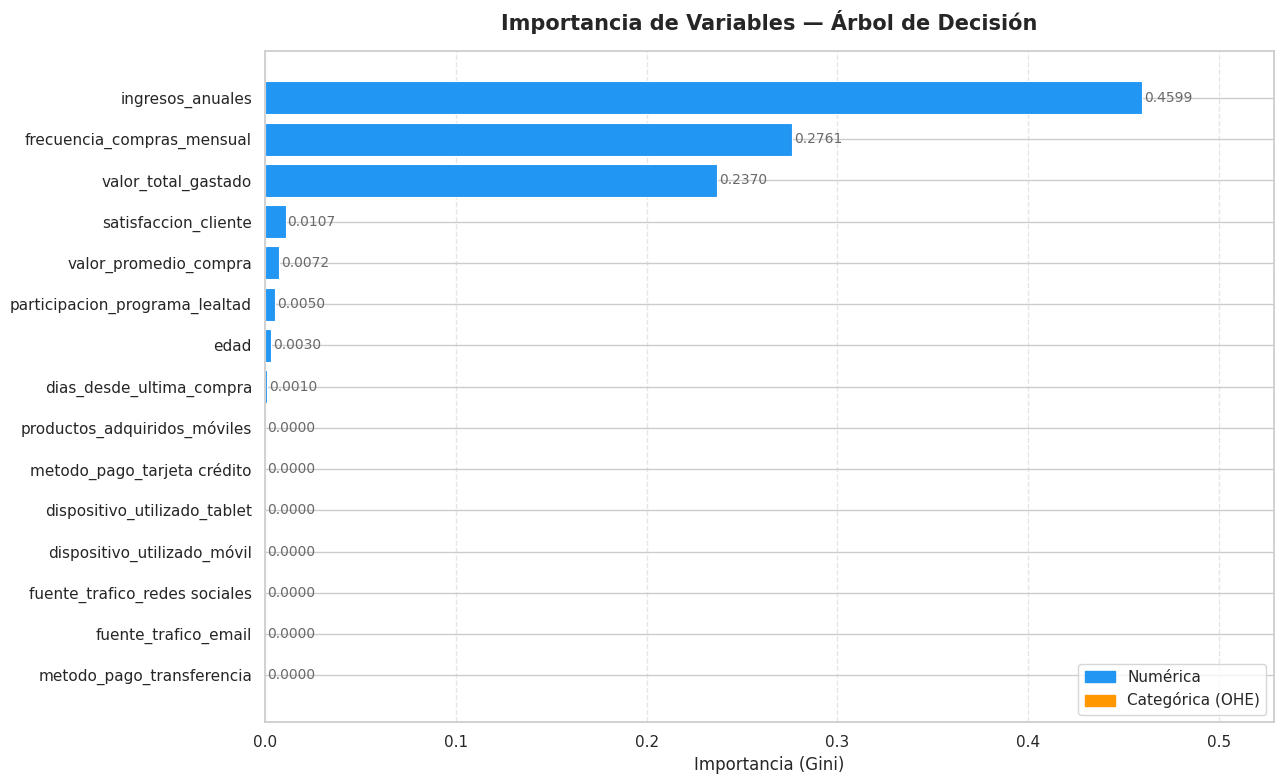


IMPORTANCIA AGREGADA (variables originales)


,Variable,Importancia Total
0,ingresos_anuales,4.599043e-01
1,frecuencia_compras_mensual,2.761179e-01
2,valor_total_gastado,2.370098e-01
3,satisfaccion_cliente,1.074058e-02
4,valor_promedio_compra,7.248127e-03
5,participacion_programa_lealtad,5.024723e-03
6,edad,2.971477e-03
7,dias_desde_ultima_compra,9.830807e-04
8,productos_adquiridos,3.432996e-16
9,metodo_pago,7.875882e-17


In [17]:
# ── 10. Importancia de variables ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── 10.1 Extraer importancias ────────────────────────────────────────────────
importancias = dt.feature_importances_
feat_names   = all_feature_names  # definido en la sección de preprocesamiento

importance_df = pd.DataFrame({
    'Variable':    feat_names,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print("=" * 55)
print("IMPORTANCIA DE VARIABLES — TOP 15")
print("=" * 55)
display(importance_df.head(15))

# ── 10.2 Gráfico — Top 15 variables ─────────────────────────────────────────
top15 = importance_df.head(15)

fig, ax = plt.subplots(figsize=(13, 8))

colores = ['#2196F3' if not any(c in v for c in
           ['dispositivo', 'fuente', 'metodo', 'productos'])
           else '#FF9800' for v in top15['Variable']]

bars = ax.barh(top15['Variable'][::-1],
               top15['Importancia'][::-1],
               color=colores[::-1], edgecolor='white',
               linewidth=0.8)

# Etiquetas de valor
for bar, val in zip(bars, top15['Importancia'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, color='dimgray')

ax.set_title("Importancia de Variables — Árbol de Decisión",
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Importancia (Gini)", fontsize=12)
ax.set_xlim(0, top15['Importancia'].max() * 1.15)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Leyenda
from matplotlib.patches import Patch
leyenda = [Patch(color='#2196F3', label='Numérica'),
           Patch(color='#FF9800', label='Categórica (OHE)')]
ax.legend(handles=leyenda, fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

# ── 10.3 Importancia agregada por variable original ──────────────────────────
print("\n" + "=" * 55)
print("IMPORTANCIA AGREGADA (variables originales)")
print("=" * 55)

def get_original_name(col):
    for cat in ['dispositivo_utilizado', 'fuente_trafico',
                'metodo_pago', 'productos_adquiridos']:
        if col.startswith(cat):
            return cat
    return col

importance_df['Variable_original'] = importance_df['Variable'].apply(get_original_name)
importancia_agregada = (importance_df.groupby('Variable_original')['Importancia']
                                     .sum()
                                     .sort_values(ascending=False)
                                     .reset_index())
importancia_agregada.columns = ['Variable', 'Importancia Total']
display(importancia_agregada)

La variable más influyente es ingresos_anuales (45.9%), seguida por frecuencia_compras_mensual (27.6%) y valor_total_gastado (23.7%), concentrando juntas más del 97% de la capacidad explicativa del modelo. Esto indica que la segmentación depende principalmente del nivel económico del cliente, su intensidad de compra y su gasto acumulado, lo cual es coherente con los perfiles obtenidos en K-Means.

En contraste, variables categóricas como dispositivo, fuente de tráfico y método de pago aportan muy poca o ninguna relevancia en las decisiones del árbol. Esto sugiere que, aunque ayudan a describir los clusters, no son determinantes para separarlos predictivamente. En términos de negocio, los resultados muestran que el valor económico y la frecuencia de interacción son los factores clave para diferenciar segmentos de clientes.

##11.Conclusiones

En este proyecto logramos segmentar exitosamente a los clientes en cinco grupos diferenciados mediante K-Means, identificando perfiles con comportamientos de compra claramente distintos en términos de ingresos, frecuencia, gasto y nivel de satisfacción. La segmentación permitió reconocer desde clientes jóvenes altamente activos hasta segmentos premium con riesgo de abandono, generando perfiles útiles para la toma de decisiones comerciales.

El análisis mostró que variables como ingresos_anuales, frecuencia_compras_mensual y valor_total_gastado son los principales factores que explican la pertenencia a un cluster, confirmando que el valor económico y la intensidad de compra son los ejes centrales de diferenciación entre clientes. Esto refuerza la validez de los clusters obtenidos y su interpretación desde una perspectiva de negocio.

Posteriormente, al entrenar el árbol de decisión con los clusters como etiquetas, obtuvimos un desempeño sobresaliente, con una precisión superior al 97%, lo que demuestra que los segmentos encontrados no solo son interpretables, sino también predecibles. Esto convierte la segmentación en una herramienta aplicable para clasificar nuevos clientes automáticamente.

Desde el punto de vista empresarial, los resultados permiten diseñar estrategias específicas para cada segmento: fidelización para clientes frecuentes, reactivación para clientes premium inactivos, mejora de experiencia para clientes insatisfechos de alto potencial y retención selectiva para segmentos de menor dinamismo. En conjunto, el proyecto evidencia cómo combinar clustering no supervisado con clasificación supervisada puede transformar datos de clientes en decisiones estratégicas accionables.